## ``DL-Classification Model - Titanic``

##### ``Sandra Ranilla-Cortina``

In [1]:
# Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten, Dropout, MaxPooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers

plt.style.use('fivethirtyeight')
np.random.seed(777)

import warnings
warnings.filterwarnings("ignore", category = UserWarning)
warnings.filterwarnings("ignore", category = FutureWarning)

#### ``Exploratory Data Analysis (EDA)``

In [2]:
# Titanic dataset
df_titanic = pd.read_csv('https://raw.githubusercontent.com/sranillac/SRC_UniOvi/refs/heads/main/ML-DL/data/Titanic/Titanic-Dataset.csv')
df_titanic.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Features type
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
# Features description
df_titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


#### ``Visualization``

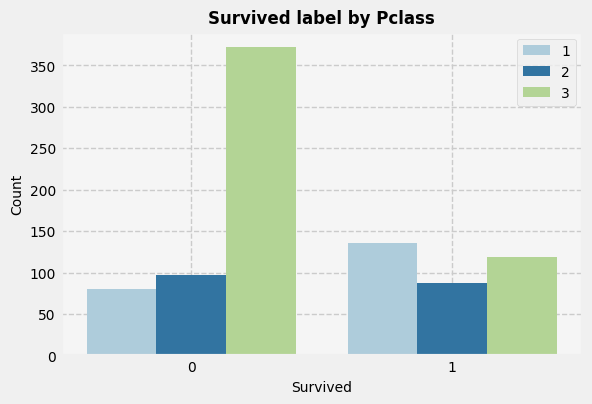

In [5]:
# Visualization - Survived label by Pclass
fig = plt.figure(figsize = (6, 4))
ax = fig.gca()
ax.set_facecolor('whitesmoke')
sns.countplot(data = df_titanic, x = 'Survived', hue = 'Pclass', palette = 'Paired')
plt.grid(linestyle = '--')
plt.title('Survived label by Pclass', fontsize = 12, fontweight = 'bold')
plt.ylabel('Count', fontsize = 10)
ax.tick_params(axis = 'y', labelsize = 10)
plt.xlabel('Survived', fontsize = 10)
ax.tick_params(axis = 'x', labelsize = 10)
legend = plt.legend(prop = {'size': 10}, frameon = True, loc = 'upper right')
legend.get_frame().set_linewidth(0.5);

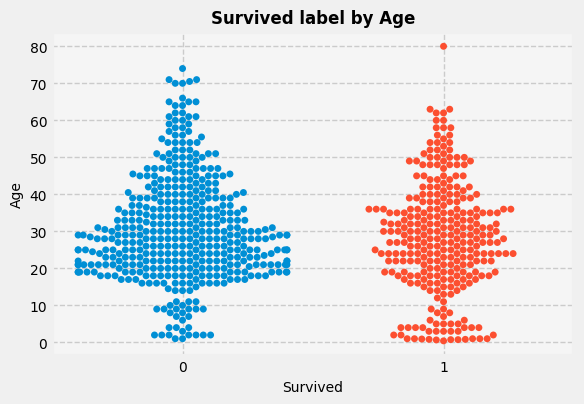

In [6]:
# Visualization - Survived label by Age
fig = plt.figure(figsize = (6, 4))
ax = fig.gca()
ax.set_facecolor('whitesmoke')
sns.swarmplot(data = df_titanic, x = 'Survived', y = 'Age', hue = 'Survived', legend = False)
plt.grid(linestyle = '--')
plt.title('Survived label by Age', fontsize = 12, fontweight = 'bold')
plt.ylabel('Age', fontsize = 10)
ax.tick_params(axis = 'y', labelsize = 10)
plt.xlabel('Survived', fontsize = 10)
ax.tick_params(axis = 'x', labelsize = 10);

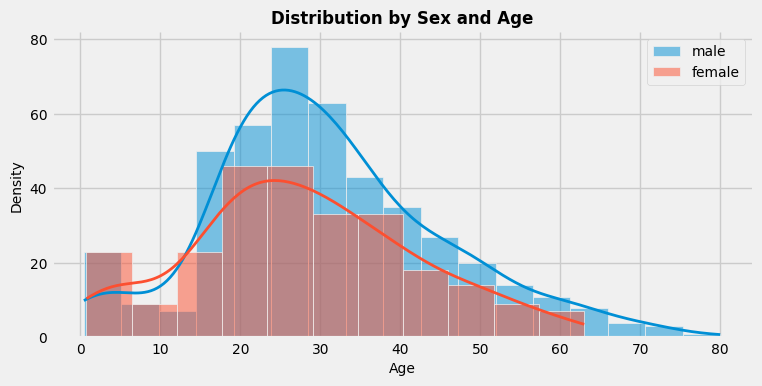

In [7]:
# Visualization - Distribution by Sex and Age
fig = sns.FacetGrid(df_titanic, hue = 'Sex', height = 4, aspect = 2)
fig.map(sns.histplot, 'Age', kde = True, line_kws = {'lw': 2})
fig.set_axis_labels('Age', 'Density', fontsize = 10) 
plt.title('Distribution by Sex and Age', fontsize = 12, fontweight = 'bold')
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)
legend = plt.legend(prop = {'size': 10}, frameon = True, loc = 'upper right')
legend.get_frame().set_linewidth(0.5);

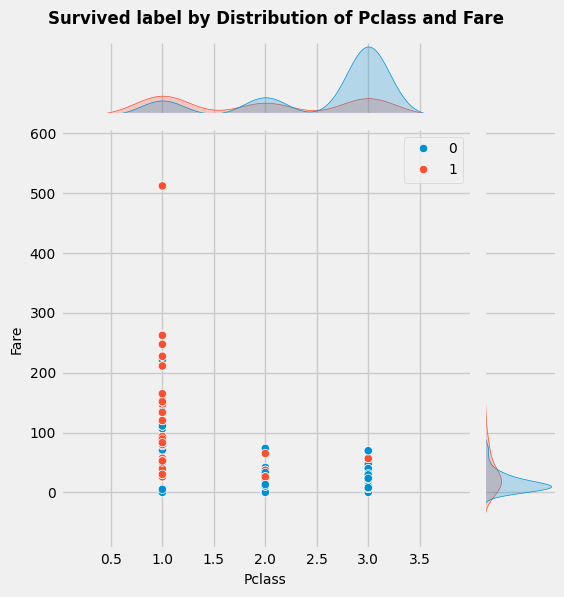

In [8]:
# Visualization - Survived label by Distribution by Pclass and Fare
fig = sns.jointplot(data = df_titanic, x = 'Pclass', y = 'Fare', color = 'olive', hue = 'Survived')
fig.ax_joint.set_xlabel('Pclass', fontsize = 10)
fig.ax_joint.set_ylabel('Fare', fontsize = 10)
fig.ax_joint.tick_params(axis = 'both', labelsize = 10)
plt.suptitle('Survived label by Distribution of Pclass and Fare', fontsize = 12, fontweight = 'bold', y = 1.02)
legend = plt.legend(prop = {'size': 10}, frameon = True, loc = 'upper right')
legend.get_frame().set_linewidth(0.5);

#### ``Data Pre-Processing``

In [9]:
# NA-values
for col in df_titanic.columns.tolist():          
    print('{} column missing values: {}'.format(col, df_titanic[col].isnull().sum()))

PassengerId column missing values: 0
Survived column missing values: 0
Pclass column missing values: 0
Name column missing values: 0
Sex column missing values: 0
Age column missing values: 177
SibSp column missing values: 0
Parch column missing values: 0
Ticket column missing values: 0
Fare column missing values: 0
Cabin column missing values: 687
Embarked column missing values: 2


In [10]:
# Fixing NA-values
df_titanic['Age'].fillna(df_titanic['Age'].median(), inplace = True) #fill w/ Median
df_titanic['Cabin'].fillna('Unknown', inplace = True) # fill w/ Unknown
df_titanic['Embarked'].fillna(df_titanic['Embarked'].mode()[0], inplace = True) # fill w/ Mode

for col in df_titanic.columns.tolist():          
    print('{} column missing values: {}'.format(col, df_titanic[col].isnull().sum()))

PassengerId column missing values: 0
Survived column missing values: 0
Pclass column missing values: 0
Name column missing values: 0
Sex column missing values: 0
Age column missing values: 0
SibSp column missing values: 0
Parch column missing values: 0
Ticket column missing values: 0
Fare column missing values: 0
Cabin column missing values: 0
Embarked column missing values: 0


In [11]:
# Feature Selection + Target
X = df_titanic.drop(['PassengerId', 'Name', 'Ticket', 'Survived'], axis = 1)
Y = df_titanic['Survived']
print(X.shape)
print(Y.shape)

(891, 8)
(891,)


In [12]:
# Categorical features
encoder = LabelEncoder()
X['Sex'] = encoder.fit_transform(X['Sex'])  # 'male' -> 0, 'female' -> 1
X['Cabin'] = encoder.fit_transform(X['Cabin'].astype(str))  # 'A', 'B', ... to numbers
X['Embarked'] = encoder.fit_transform(X['Embarked'].astype(str))  # 'C', 'Q', 'S' -> 0, 1, 2
X['Pclass'] = encoder.fit_transform(X['Pclass'].astype(str))  # 1, 2, 3 en 0, 1, 2
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,2,1,22.0,1,0,7.2500,147,2
1,0,0,38.0,1,0,71.2833,81,0
2,2,0,26.0,0,0,7.9250,147,2
3,0,0,35.0,1,0,53.1000,55,2
4,2,1,35.0,0,0,8.0500,147,2


In [13]:
# Numerical features
sc = StandardScaler()
X[['Age', 'Fare']] = sc.fit_transform(X[['Age', 'Fare']])

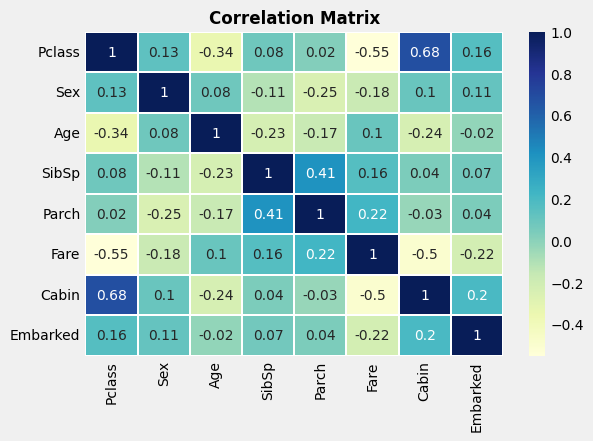

In [14]:
# Correlation Matrix
mcorr = X.corr().round(2)
fig = plt.figure(figsize = (6, 4))
sns.heatmap(mcorr, annot = True, linewidth = 0.2, cmap = 'YlGnBu', annot_kws = {'size': 10})
plt.title('Correlation Matrix', fontsize = 12, fontweight = 'bold')
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)
cbar = plt.gca().collections[0].colorbar
cbar.ax.tick_params(labelsize = 10)

In [15]:
# Train-vs-Test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.25, random_state = 1)
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(668, 8)
(668,)
(223, 8)
(223,)


#### ``Modeling``

In [16]:
# Neural Network model
model_nn = Sequential(name = 'Model_NN')

model_nn.add(Dense(64, activation = 'relu', input_shape = (X_train.shape[1],), kernel_regularizer = regularizers.l2(0.001), name = 'hidden_layer_1'))
model_nn.add(Dropout(0.2, name = 'dropout_1'))

model_nn.add(Dense(32, activation = 'relu', name = 'hidden_layer_2'))

model_nn.add(Dense(1, activation = 'sigmoid', name = 'output_layer'))

model_nn.summary()

Model: "Model_NN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Compilation + Training
model_nn.compile(loss = 'binary_crossentropy', optimizer = Adam(learning_rate = 0.001), metrics = ['accuracy'])
history_nn = model_nn.fit(X_train, Y_train, epochs = 200, batch_size = 64, validation_split = 0.2, verbose = 1)

Epoch 1/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5797 - loss: 2.1061 - val_accuracy: 0.3284 - val_loss: 0.8306
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4920 - loss: 2.0327 - val_accuracy: 0.6716 - val_loss: 0.6223
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5541 - loss: 1.5296 - val_accuracy: 0.3284 - val_loss: 0.8017
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5663 - loss: 1.5165 - val_accuracy: 0.3284 - val_loss: 0.9378
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5506 - loss: 1.4297 - val_accuracy: 0.3284 - val_loss: 1.2183
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5268 - loss: 1.1716 - val_accuracy: 0.7239 - val_loss: 0.6531
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5936 - loss: 1.2052 - val_accuracy: 0.3284 - val_loss: 1.1692
Epoch 8/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5368 - loss: 1.0303 - val_accuracy: 0.7537 - val_loss: 0.6790

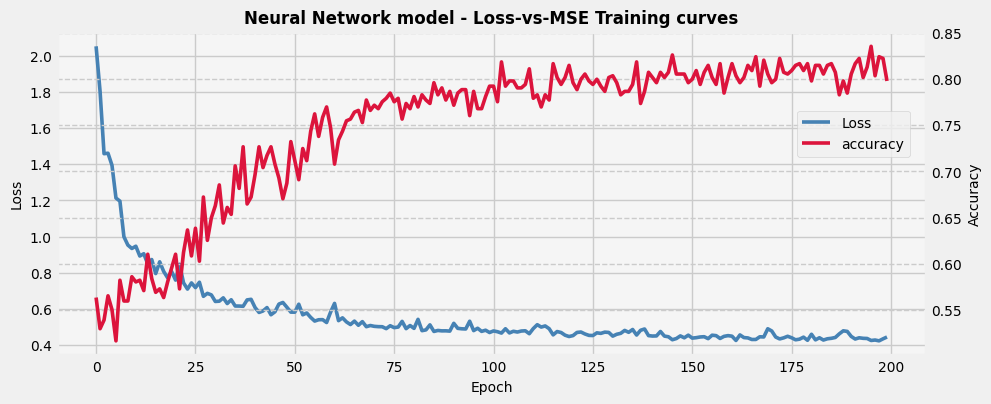

In [18]:
# Loss-vs-MSE Training curves
fig = plt.figure(figsize = (10, 4))
ax1 = fig.gca()
ax1.set_facecolor('whitesmoke')
ax1.plot(history_nn.history['loss'], label = 'Loss', color = 'steelblue', linewidth = 2.6)
ax1.set_ylabel('Loss', fontsize = 10)
ax1.tick_params(axis = 'y', labelsize = 10)
ax2 = ax1.twinx()
ax2.plot(history_nn.history['accuracy'], label = 'accuracy', color = 'crimson', linewidth = 2.6)
ax2.set_ylabel('Accuracy', fontsize = 10)
ax2.tick_params(axis = 'y', labelsize = 10)
ax1.set_xlabel('Epoch', fontsize = 10)
ax1.tick_params(axis = 'x', labelsize = 10)
plt.title('Neural Network model - Loss-vs-MSE Training curves', fontsize = 12, fontweight = 'bold')
plt.grid(linestyle = '--')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
fig.legend(lines1 + lines2, labels1 + labels2, loc = 'upper right', bbox_to_anchor = (0.94, 0.70), fontsize = 10)
legend.get_frame().set_linewidth(0.5);

In [19]:
# Evaluation Metrics function
def eval_metrics(y, y_pred):
    mc = confusion_matrix(y, y_pred)
    acc = accuracy_score(y, y_pred)
    cr = classification_report(y, y_pred)
    return mc, acc, cr

In [20]:
# Model Prediction
y_test_pred_probs = model_nn.predict(X_test, verbose = 0).flatten()
y_test_pred = (y_test_pred_probs >= 0.5).astype(int)

# Evaluation
mc_nn, acc_nn, cr_nn = eval_metrics(Y_test, y_test_pred)

print(f'Neural Network (NN) model - Confusion Matrix:')
print(mc_nn)
print('')
print(f'Neural Network (NN) model - Accuracy: {acc_nn:.2f}')
print('')
print(f'Neural Network (NN) model - Classification Report:')
print(cr_nn)

Neural Network (NN) model - Confusion Matrix:
[[120   8]
 [ 42  53]]

Neural Network (NN) model - Accuracy: 0.78

Neural Network (NN) model - Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.94      0.83       128
           1       0.87      0.56      0.68        95

    accuracy                           0.78       223
   macro avg       0.80      0.75      0.75       223
weighted avg       0.80      0.78      0.76       223



In [21]:
# Convolutional Neural Network model

X_train = X_train.values.reshape(-1, X_train.shape[1], 1)
X_test = X_test.values.reshape(-1, X_test.shape[1], 1)

model_cnn = Sequential(name = 'Model_CNN')

model_cnn.add(Conv1D(64, 3, activation = 'relu', input_shape = (X_train.shape[1], 1), padding = 'same', kernel_regularizer = regularizers.l2(0.001), name = 'cnn_layer_1'))
model_cnn.add(MaxPooling1D(2, name = 'maxpool_1'))
model_cnn.add(Dropout(0.2, name = 'dropout_1'))

model_cnn.add(Flatten(name = 'flatten_layer'))

model_cnn.add(Dense(32, activation = 'relu', kernel_regularizer = regularizers.l2(0.001), name = 'hidden_layer_2'))
model_cnn.add(Dropout(0.2, name = 'dropout_2'))

model_cnn.add(Dense(1, activation = 'sigmoid', name = 'output_layer'))

model_cnn.summary()

Model: "Model_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cnn_layer_1 (Conv1D)            │ (None, 8, 64)          │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling1D)        │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_layer (Flatten)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,513 (33.25 KB)

 Trainable params: 8,513 (33.25 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Compilation + Training
model_cnn.compile(loss = 'binary_crossentropy', optimizer = Adam(learning_rate = 0.001), metrics = ['accuracy'])
history_cnn = model_cnn.fit(X_train, Y_train, epochs = 200, batch_size = 64, validation_split = 0.2, verbose = 1)

Epoch 1/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4474 - loss: 4.9455 - val_accuracy: 0.6716 - val_loss: 2.4354
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6157 - loss: 2.7175 - val_accuracy: 0.6716 - val_loss: 0.6721
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5161 - loss: 1.7129 - val_accuracy: 0.6716 - val_loss: 0.6558
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5035 - loss: 1.4197 - val_accuracy: 0.6716 - val_loss: 0.9230
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5948 - loss: 1.2014 - val_accuracy: 0.6716 - val_loss: 0.6557
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5508 - loss: 1.0483 - val_accuracy: 0.6716 - val_loss: 0.7040
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5286 - loss: 0.9705 - val_accuracy: 0.6716 - val_loss: 0.6505
Epoch 8/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6055 - loss: 0.7897 - val_accuracy: 0.6716 - val_loss: 0.6539

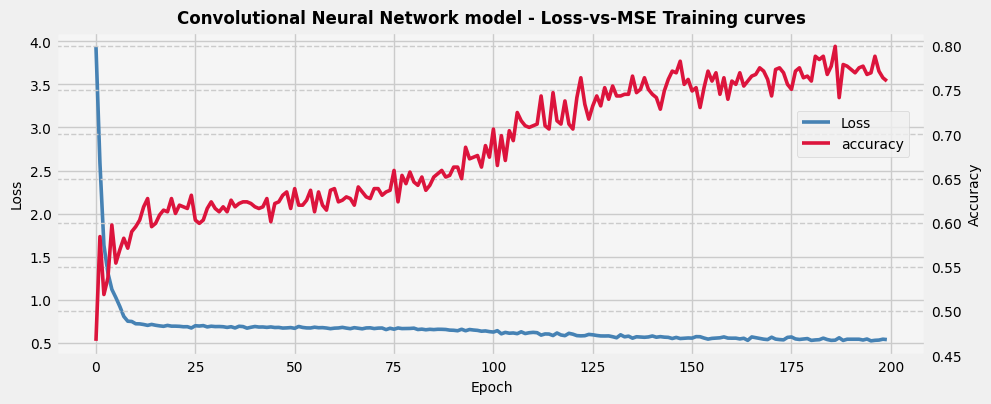

In [23]:
# Loss-vs-MSE Training curves
fig = plt.figure(figsize = (10, 4))
ax1 = fig.gca()
ax1.set_facecolor('whitesmoke')
ax1.plot(history_cnn.history['loss'], label = 'Loss', color = 'steelblue', linewidth = 2.6)
ax1.set_ylabel('Loss', fontsize = 10)
ax1.tick_params(axis = 'y', labelsize = 10)
ax2 = ax1.twinx()
ax2.plot(history_cnn.history['accuracy'], label = 'accuracy', color = 'crimson', linewidth = 2.6)
ax2.set_ylabel('Accuracy', fontsize = 10)
ax2.tick_params(axis = 'y', labelsize = 10)
ax1.set_xlabel('Epoch', fontsize = 10)
ax1.tick_params(axis = 'x', labelsize = 10)
plt.title('Convolutional Neural Network model - Loss-vs-MSE Training curves', fontsize = 12, fontweight = 'bold')
plt.grid(linestyle = '--')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
fig.legend(lines1 + lines2, labels1 + labels2, loc = 'upper right', bbox_to_anchor = (0.94, 0.70), fontsize = 10)
legend.get_frame().set_linewidth(0.5);

In [24]:
# Model Prediction
y_test_pred_probs = model_cnn.predict(X_test, verbose = 0).flatten()
y_test_pred = (y_test_pred_probs >= 0.5).astype(int)

# Evaluation
mc_cnn, acc_cnn, cr_cnn = eval_metrics(Y_test, y_test_pred)

print(f'Convolutional Neural Network (CNN) model - Confusion Matrix:')
print(mc_cnn)
print('')
print(f'Convolutional Neural Network (CNN) model - Accuracy: {acc_cnn:.2f}')
print('')
print(f'Convolutional Neural Network (CNN) model - Classification Report:')
print(cr_cnn)

Convolutional Neural Network (CNN) model - Confusion Matrix:
[[109  19]
 [ 23  72]]

Convolutional Neural Network (CNN) model - Accuracy: 0.81

Convolutional Neural Network (CNN) model - Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       128
           1       0.79      0.76      0.77        95

    accuracy                           0.81       223
   macro avg       0.81      0.80      0.81       223
weighted avg       0.81      0.81      0.81       223



Which is the **``best performing model``**?  

Let us recall that the best performing model in terms of **Machine Learning** was **Random Forest (RF) model**, achieving an accuracy of $80\%$. While this model performed well in predicting survivor cases (**class 0**), it struggled with non-survivor cases (**class 1**), obtaining a recall of just $0.61$.  

- The **Neural Network (NN) model**: recorded an accuracy of $78\%$ and showed moderately balanced performance, with a precision of $0.74$ and recall of $0.94$ **class 0**, and a precision of $0.87$ and recall of $0.56$ for **class 1**. Despite its ability to capture complex patterns, the model underperformed compared to **Random Forest** and struggled particularly with the recall of non-survivor cases. This suggests the model may benefit from further regularization or rebalancing techniques.  

- The **Convolutional Neural Network (CNN) model**: achieved a slightly higher accuracy of $81\%$, with strong performance on both classes — precision of $0.83$ and recall of $0.85$ for **class 0**, and precision of $0.79$ and recall of $0.76$ for **class 1**.  Unlike traditional expectations for tabular data, the **CNN** demonstrated robust classification ability and outperformed both the NN and RF models in overall accuracy and balance.  

The **``Convolutional Neural Network (CNN) model``** stands out as the **best performing model**, delivering the highest accuracy alongside balanced and reliable performance across both classes. It outperforms **Random Forest** and **Neural Network models**, making it the most suitable choice for this classification task.